# Personal Information
Name: **Alexandra Holíková**

StudentID: **14236788**

Email: [**alexandra.holikova@student.uva.nl**](alexandra.holikova@student.uva.nl)

Github link: https://github.com/alexandraholik/MSc_Thesis.git

# English detection experiments

This notebook evaluates automatic methods for detecting whether an English headline quote is **contextomized** or **modified** relative to its source text in the article body. The experiments use the matched English dataset created in the previous stage, including headline quotes, best-matching body quotes, sentence-level context, and manual gold labels [file:3].

The notebook compares multiple detection strategies, ranging from a simple cosine-similarity baseline to zero-shot and chain-of-thought prompting with GPT-4o under different input conditions. Specifically, the experiments test whether classification performs better when the model sees the best-matching body quote, a local sentence window, or the full article text [file:3].

Evaluation is conducted on a labeled test set of 100 English articles, of which 10 are annotated as contextomized and 90 as modified. Performance is assessed primarily with AUC and F1, with additional inspection through classification reports, bootstrapped confidence intervals, and ROC/precision-recall visualizations [file:3].

In [15]:
import pandas as pd
import numpy as np
from sklearn.metrics import f1_score, roc_auc_score, classification_report
import openai, json, os, time, warnings
import matplotlib.pyplot as plt
import os
warnings.filterwarnings('ignore')
from dotenv import load_dotenv
load_dotenv()

THRESHOLD = 0.5

df = pd.read_csv('data_new/english_matched.csv')
df = df.dropna(subset=['label']).copy()
df['label'] = df['label'].astype(int)
for col in ['prev_sentence', 'next_sentence', 'best_body_sentence', 'best_body_quote']:
    df[col] = df[col].fillna('')

y_true = df['label'].values
print(f'Test set: {len(df)} articles')
print(f'Contextomized: {y_true.sum()}  |  Modified: {(y_true==0).sum()}')

Test set: 100 articles
Contextomized: 10  |  Modified: 90


In [2]:
def build_premise(row):
    parts = [row['prev_sentence'], row['best_body_sentence'], row['next_sentence']]
    return ' '.join(p for p in parts if p).strip()

def evaluate(y_true, scores, threshold=THRESHOLD):
    preds = (scores >= threshold).astype(int)
    auc   = roc_auc_score(y_true, scores)
    f1    = f1_score(y_true, preds, zero_division=0)
    print(f'AUC : {auc:.3f}  |  F1 (τ={threshold}) : {f1:.3f}')
    print(classification_report(y_true, preds, target_names=['modified', 'contextomized']))
    return preds, auc, f1

## Approach 1 — Cosine Similarity Threshold (τ=0.5)

In [3]:
cosine_scores_sent = 1 - df['best_sim'].values
print('--- sentence window ---')
cosine_preds_sent, cosine_auc_sent, cosine_f1_sent = evaluate(y_true, cosine_scores_sent)

cosine_scores_q2q = 1 - df['best_quote_sim'].values
print('--- quote-to-quote ---')
cosine_preds_q2q, cosine_auc_q2q, cosine_f1_q2q = evaluate(y_true, cosine_scores_q2q)

--- sentence window ---
AUC : 0.609  |  F1 (τ=0.5) : 0.091
               precision    recall  f1-score   support

     modified       0.90      0.88      0.89        90
contextomized       0.08      0.10      0.09        10

     accuracy                           0.80       100
    macro avg       0.49      0.49      0.49       100
 weighted avg       0.82      0.80      0.81       100

--- quote-to-quote ---
AUC : 0.761  |  F1 (τ=0.5) : 0.348
               precision    recall  f1-score   support

     modified       0.93      0.90      0.92        90
contextomized       0.31      0.40      0.35        10

     accuracy                           0.85       100
    macro avg       0.62      0.65      0.63       100
 weighted avg       0.87      0.85      0.86       100



## Approach 2 — GPT-4o Zero-Shot Direct (COntext window)

In [4]:
client = openai.OpenAI(api_key=os.environ['OPENAI_API_KEY'])

SYSTEM_DIRECT = """You are a journalism ethics expert specialising in quote accuracy.

Definitions:
- MODIFIED: The headline quote faithfully preserves the speaker's intended meaning. Minor editorial changes are acceptable: grammatical adaptation, brevity, pronoun replacement, or paraphrase that does not alter what the speaker actually claimed.
- CONTEXTOMIZED: The headline quote distorts the speaker's intended meaning by removing qualifications, stripping hedges, omitting key context, or combining fragments in a way that produces a materially different claim than the speaker made.

The bar for CONTEXTOMIZED is semantic distortion, not surface difference. When in doubt, prefer MODIFIED.

You will receive a headline quote and the body text where it originated.
Output ONLY valid JSON with exactly two fields:
- \"label\": \"CONTEXTOMIZED\" or \"MODIFIED\"
- \"probability\": float 0.0-1.0, your estimated probability that the quote is contextomized"""

def classify_direct(row, body_field='premise'):
    if body_field == 'premise':
        body = build_premise(row)
        label = 'BODY CONTEXT'
    elif body_field == 'quote':
        body = row['best_body_quote']
        label = 'BODY QUOTE'
    else:
        body = str(row['full_text'])[:6000]
        label = 'FULL ARTICLE'
    user_msg = f'HEADLINE QUOTE: "{row["headline_quote"]}"\n{label}: "{body}"'
    response = client.chat.completions.create(
        model='gpt-4o',
        messages=[
            {'role': 'system', 'content': SYSTEM_DIRECT},
            {'role': 'user',   'content': user_msg}
        ],
        temperature=0,
        max_tokens=60
    )
    text   = response.choices[0].message.content.strip().replace('```json','').replace('```','')
    parsed = json.loads(text)
    return parsed['label'], float(parsed['probability'])

print('Pilot (5 rows) — sentence window:')
for _, row in df.head(5).iterrows():
    label, prob = classify_direct(row, 'premise')
    print(f'  gt={row["label"]}  pred={label}  prob={prob:.2f}  |  {row["headline_quote"][:70]}')
    time.sleep(0.3)

Pilot (5 rows) — sentence window:
  gt=1  pred=CONTEXTOMIZED  prob=0.90  |  We can sell anything, from your gumboots to your farm
  gt=1  pred=CONTEXTOMIZED  prob=0.95  |  wanted to fire candidates based on their looks
  gt=1  pred=MODIFIED  prob=0.20  |  We need to burn down Arab villages - this is war!
  gt=1  pred=CONTEXTOMIZED  prob=0.85  |  most dangerous president of all time
  gt=1  pred=MODIFIED  prob=0.20  |  Those who wanted us out are disappointed


In [5]:
gpt_labels, gpt_scores = [], []
for i, (_, row) in enumerate(df.iterrows()):
    try:
        label, prob = classify_direct(row, 'premise')
        gpt_labels.append(1 if label == 'CONTEXTOMIZED' else 0)
        gpt_scores.append(prob)
    except Exception as e:
        print(f'Row {i} failed: {e}')
        gpt_labels.append(0); gpt_scores.append(0.5)
    if (i + 1) % 10 == 0: print(f'  {i+1}/{len(df)} done')
    time.sleep(0.3)

gpt_scores = np.array(gpt_scores)
gpt_preds, gpt_auc, gpt_f1 = evaluate(y_true, gpt_scores)

  10/100 done
  20/100 done
  30/100 done
  40/100 done
  50/100 done
  60/100 done
  70/100 done
  80/100 done
  90/100 done
  100/100 done
AUC : 0.773  |  F1 (τ=0.5) : 0.302
               precision    recall  f1-score   support

     modified       0.96      0.61      0.75        90
contextomized       0.19      0.80      0.30        10

     accuracy                           0.63       100
    macro avg       0.58      0.71      0.53       100
 weighted avg       0.89      0.63      0.70       100



## Approach 3 — GPT-4o Zero-Shot Direct (Quote-to-Quote)

In [6]:
print('Pilot (5 rows) — quote-to-quote:')
for _, row in df.head(5).iterrows():
    label, prob = classify_direct(row, 'quote')
    print(f'  gt={row["label"]}  pred={label}  prob={prob:.2f}  |  {row["headline_quote"][:70]}')
    time.sleep(0.3)

Pilot (5 rows) — quote-to-quote:
  gt=1  pred=CONTEXTOMIZED  prob=0.85  |  We can sell anything, from your gumboots to your farm
  gt=1  pred=CONTEXTOMIZED  prob=0.95  |  wanted to fire candidates based on their looks
  gt=1  pred=MODIFIED  prob=0.80  |  We need to burn down Arab villages - this is war!
  gt=1  pred=CONTEXTOMIZED  prob=0.85  |  most dangerous president of all time
  gt=1  pred=CONTEXTOMIZED  prob=0.80  |  Those who wanted us out are disappointed


In [7]:
gpt_q2q_labels, gpt_q2q_scores = [], []
for i, (_, row) in enumerate(df.iterrows()):
    try:
        label, prob = classify_direct(row, 'quote')
        gpt_q2q_labels.append(1 if label == 'CONTEXTOMIZED' else 0)
        gpt_q2q_scores.append(prob)
    except Exception as e:
        print(f'Row {i} failed: {e}')
        gpt_q2q_labels.append(0); gpt_q2q_scores.append(0.5)
    if (i + 1) % 10 == 0: print(f'  {i+1}/{len(df)} done')
    time.sleep(0.3)

gpt_q2q_scores = np.array(gpt_q2q_scores)
gpt_q2q_preds, gpt_q2q_auc, gpt_q2q_f1 = evaluate(y_true, gpt_q2q_scores)

  10/100 done
  20/100 done
  30/100 done
  40/100 done
  50/100 done
  60/100 done
  70/100 done
  80/100 done
  90/100 done
  100/100 done
AUC : 0.829  |  F1 (τ=0.5) : 0.392
               precision    recall  f1-score   support

     modified       1.00      0.66      0.79        90
contextomized       0.24      1.00      0.39        10

     accuracy                           0.69       100
    macro avg       0.62      0.83      0.59       100
 weighted avg       0.92      0.69      0.75       100



## Approach 4 — GPT-4o Zero-Shot Direct (Full Article)

In [8]:
gpt_full_labels, gpt_full_scores = [], []
for i, (_, row) in enumerate(df.iterrows()):
    try:
        label, prob = classify_direct(row, 'full')
        gpt_full_labels.append(1 if label == 'CONTEXTOMIZED' else 0)
        gpt_full_scores.append(prob)
    except Exception as e:
        print(f'Row {i} failed: {e}')
        gpt_full_labels.append(0); gpt_full_scores.append(0.5)
    if (i + 1) % 10 == 0: print(f'  {i+1}/{len(df)} done')
    time.sleep(0.3)

gpt_full_scores = np.array(gpt_full_scores)
gpt_full_preds, gpt_full_auc, gpt_full_f1 = evaluate(y_true, gpt_full_scores)

  10/100 done
  20/100 done
  30/100 done
  40/100 done
  50/100 done
  60/100 done
  70/100 done
  80/100 done
  90/100 done
  100/100 done
AUC : 0.788  |  F1 (τ=0.5) : 0.356
               precision    recall  f1-score   support

     modified       0.97      0.70      0.81        90
contextomized       0.23      0.80      0.36        10

     accuracy                           0.71       100
    macro avg       0.60      0.75      0.58       100
 weighted avg       0.90      0.71      0.77       100



## Approach 5 — GPT-4o Chain-of-Thought (Context Window )

In [9]:
SYSTEM_COT = """You are a journalism ethics expert specialising in quote accuracy.

Definitions:
- MODIFIED: The headline quote faithfully preserves the speaker's meaning.
- CONTEXTOMIZED: The headline quote distorts the speaker's intended meaning by removing context, altering emphasis, or combining fragments in a misleading way.

Reason step by step, then output ONLY valid JSON with exactly four fields:
- \"step1\": What is the speaker's intended meaning in the body context? (1 sentence)
- \"step2\": Does the headline quote preserve or distort that meaning? (1 sentence)
- \"label\": \"CONTEXTOMIZED\" or \"MODIFIED\"
- \"probability\": float 0.0-1.0, your estimated probability that the quote is contextomized"""

def classify_cot(row, body_field='premise'):
    if body_field == 'premise':
        body = build_premise(row)
        label = 'BODY CONTEXT'
    elif body_field == 'quote':
        body = row['best_body_quote']
        label = 'BODY QUOTE'
    else:
        body = str(row['full_text'])[:6000]
        label = 'FULL ARTICLE'
    user_msg = f'HEADLINE QUOTE: "{row["headline_quote"]}"\n{label}: "{body}"'
    response = client.chat.completions.create(
        model='gpt-4o',
        messages=[
            {'role': 'system', 'content': SYSTEM_COT},
            {'role': 'user',   'content': user_msg}
        ],
        temperature=0,
        max_tokens=200
    )
    text   = response.choices[0].message.content.strip().replace('```json','').replace('```','')
    parsed = json.loads(text)
    return parsed['label'], float(parsed['probability'])

print('Pilot (5 rows) — CoT sentence window:')
for _, row in df.head(5).iterrows():
    label, prob = classify_cot(row, 'premise')
    print(f'  gt={row["label"]}  pred={label}  prob={prob:.2f}  |  {row["headline_quote"][:70]}')
    time.sleep(0.3)

Pilot (5 rows) — CoT sentence window:
  gt=1  pred=CONTEXTOMIZED  prob=0.90  |  We can sell anything, from your gumboots to your farm
  gt=1  pred=CONTEXTOMIZED  prob=0.95  |  wanted to fire candidates based on their looks
  gt=1  pred=MODIFIED  prob=0.10  |  We need to burn down Arab villages - this is war!
  gt=1  pred=CONTEXTOMIZED  prob=0.90  |  most dangerous president of all time
  gt=1  pred=CONTEXTOMIZED  prob=0.85  |  Those who wanted us out are disappointed


In [10]:
cot_labels, cot_scores = [], []
for i, (_, row) in enumerate(df.iterrows()):
    try:
        label, prob = classify_cot(row, 'premise')
        cot_labels.append(1 if label == 'CONTEXTOMIZED' else 0)
        cot_scores.append(prob)
    except Exception as e:
        print(f'Row {i} failed: {e}')
        cot_labels.append(0); cot_scores.append(0.5)
    if (i + 1) % 10 == 0: print(f'  {i+1}/{len(df)} done')
    time.sleep(0.3)

cot_scores = np.array(cot_scores)
cot_preds, cot_auc, cot_f1 = evaluate(y_true, cot_scores)

  10/100 done
  20/100 done
  30/100 done
  40/100 done
  50/100 done
  60/100 done
  70/100 done
  80/100 done
  90/100 done
  100/100 done
AUC : 0.743  |  F1 (τ=0.5) : 0.291
               precision    recall  f1-score   support

     modified       0.96      0.59      0.73        90
contextomized       0.18      0.80      0.29        10

     accuracy                           0.61       100
    macro avg       0.57      0.69      0.51       100
 weighted avg       0.89      0.61      0.69       100



## Approach 6 — GPT-4o Chain-of-Thought (Quote-to-Quote)

In [11]:
cot_q2q_labels, cot_q2q_scores = [], []
for i, (_, row) in enumerate(df.iterrows()):
    try:
        label, prob = classify_cot(row, 'quote')
        cot_q2q_labels.append(1 if label == 'CONTEXTOMIZED' else 0)
        cot_q2q_scores.append(prob)
    except Exception as e:
        print(f'Row {i} failed: {e}')
        cot_q2q_labels.append(0); cot_q2q_scores.append(0.5)
    if (i + 1) % 10 == 0: print(f'  {i+1}/{len(df)} done')
    time.sleep(0.3)

cot_q2q_scores = np.array(cot_q2q_scores)
cot_q2q_preds, cot_q2q_auc, cot_q2q_f1 = evaluate(y_true, cot_q2q_scores)

  10/100 done
  20/100 done
  30/100 done
  40/100 done
Row 42 failed: Expecting value: line 1 column 1 (char 0)
  50/100 done
  60/100 done
  70/100 done
  80/100 done
  90/100 done
  100/100 done
AUC : 0.727  |  F1 (τ=0.5) : 0.261
               precision    recall  f1-score   support

     modified       0.98      0.44      0.61        90
contextomized       0.15      0.90      0.26        10

     accuracy                           0.49       100
    macro avg       0.56      0.67      0.44       100
 weighted avg       0.89      0.49      0.58       100



## Approach 7 — GPT-4o Chain-of-Thought (Full Article)

In [12]:
cot_full_labels, cot_full_scores = [], []
for i, (_, row) in enumerate(df.iterrows()):
    try:
        label, prob = classify_cot(row, 'full')
        cot_full_labels.append(1 if label == 'CONTEXTOMIZED' else 0)
        cot_full_scores.append(prob)
    except Exception as e:
        print(f'Row {i} failed: {e}')
        cot_full_labels.append(0); cot_full_scores.append(0.5)
    if (i + 1) % 10 == 0: print(f'  {i+1}/{len(df)} done')
    time.sleep(0.3)

cot_full_scores = np.array(cot_full_scores)
cot_full_preds, cot_full_auc, cot_full_f1 = evaluate(y_true, cot_full_scores)

  10/100 done
  20/100 done
  30/100 done
  40/100 done
  50/100 done
  60/100 done
  70/100 done
  80/100 done
  90/100 done
  100/100 done
AUC : 0.680  |  F1 (τ=0.5) : 0.237
               precision    recall  f1-score   support

     modified       0.94      0.53      0.68        90
contextomized       0.14      0.70      0.24        10

     accuracy                           0.55       100
    macro avg       0.54      0.62      0.46       100
 weighted avg       0.86      0.55      0.64       100



## Bootstrapped AUC CIs

In [13]:
def bootstrap_auc_ci(y_true, y_scores, n_bootstrap=10_000, ci=0.95, seed=42):
    rng = np.random.default_rng(seed)
    n = len(y_true)
    aucs = []
    for _ in range(n_bootstrap):
        idx = rng.integers(0, n, size=n)
        if len(np.unique(y_true[idx])) < 2:
            continue
        aucs.append(roc_auc_score(y_true[idx], y_scores[idx]))
    alpha = (1 - ci) / 2
    point = roc_auc_score(y_true, y_scores)
    return point, np.percentile(aucs, 100 * alpha), np.percentile(aucs, 100 * (1 - alpha))

en_methods = {
    'Cosine (sentence)':      cosine_scores_sent,
    'Cosine (quote)':         cosine_scores_q2q,
    'GPT-4o Direct (sent)':   gpt_scores,
    'GPT-4o Direct (quote)':  gpt_q2q_scores,
    'GPT-4o Direct (full)':   gpt_full_scores,
    'GPT-4o CoT (sent)':      cot_scores,
    'GPT-4o CoT (quote)':     cot_q2q_scores,
    'GPT-4o CoT (full)':      cot_full_scores,
}

print(f"{'Method':<28} {'AUC':>6}  {'95% CI (bootstrap)'}")
print('-' * 58)
for name, scores in en_methods.items():
    auc, lo, hi = bootstrap_auc_ci(y_true, scores)
    print(f'{name:<28} {auc:.3f}  [{lo:.3f} – {hi:.3f}]')

print(f'\nNote: n=100, {y_true.sum()} positives. Wide CIs expected.')

Method                          AUC  95% CI (bootstrap)
----------------------------------------------------------
Cosine (sentence)            0.609  [0.451 – 0.763]
Cosine (quote)               0.761  [0.607 – 0.895]
GPT-4o Direct (sent)         0.773  [0.647 – 0.884]
GPT-4o Direct (quote)        0.829  [0.729 – 0.915]
GPT-4o Direct (full)         0.788  [0.679 – 0.883]
GPT-4o CoT (sent)            0.743  [0.560 – 0.898]
GPT-4o CoT (quote)           0.727  [0.571 – 0.860]
GPT-4o CoT (full)            0.680  [0.495 – 0.840]

Note: n=100, 10 positives. Wide CIs expected.


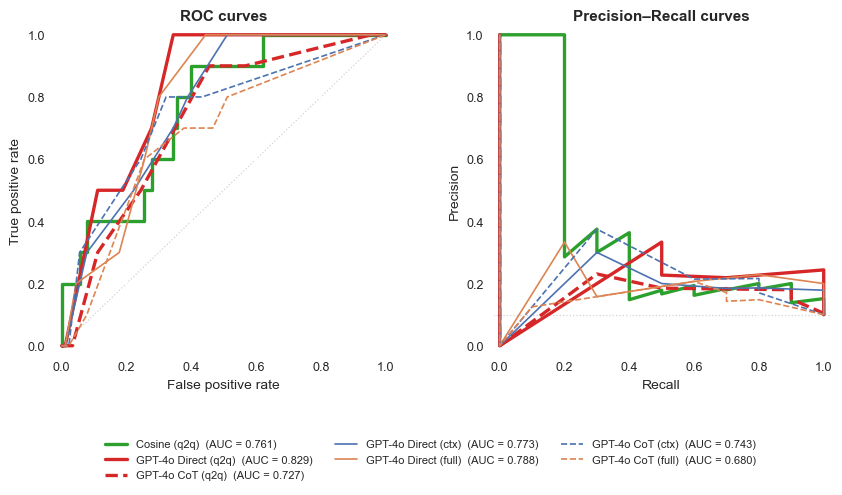

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, precision_recall_curve, roc_auc_score

matplotlib.rcParams['axes.facecolor'] = 'white'
matplotlib.rcParams['figure.facecolor'] = 'white'

# --- Load data ---
df = pd.read_csv('data_new/english_predictions.csv')
df = df.dropna(subset=['label']).copy()
df['label'] = df['label'].astype(int)
y_true = df['label'].values

cosine_scores_q2q = df['score_cosine_q2q'].values
gpt_q2q_scores    = df['score_gpt_q2q'].values
cot_q2q_scores    = df['score_cot_q2q'].values
gpt_scores        = df['score_gpt_sent'].values
gpt_full_scores   = df['score_gpt_full'].values
cot_scores        = df['score_cot_sent'].values
cot_full_scores   = df['score_cot_full'].values

# --- Method list ---
METHODS_EN = [
    # q2q methods (thick lines)
    ('Cosine (q2q)',         cosine_scores_q2q, '#2ca02c', '-',  2.4),
    ('GPT-4o Direct (q2q)', gpt_q2q_scores,    '#d62728', '-',  2.4),
    ('GPT-4o CoT (q2q)',    cot_q2q_scores,    '#d62728', '--', 2.4),
    # ctx / full methods (thin lines)
    ('GPT-4o Direct (ctx)',  gpt_scores,        '#4C72B0', '-',  1.2),
    ('GPT-4o Direct (full)', gpt_full_scores,   '#DD8452', '-',  1.2),
    ('GPT-4o CoT (ctx)',     cot_scores,        '#4C72B0', '--', 1.2),
    ('GPT-4o CoT (full)',    cot_full_scores,   '#DD8452', '--', 1.2),
]

# --- Plot ---
fig, (ax_roc, ax_pr) = plt.subplots(1, 2, figsize=(10, 4.2))
fig.subplots_adjust(wspace=0.30)

ax_roc.plot([0, 1], [0, 1], color='lightgrey', lw=0.9, linestyle=':', zorder=0)
ax_pr.axhline(y_true.mean(), color='lightgrey', lw=0.9, linestyle=':', zorder=0)

for label, scores, color, ls, lw in METHODS_EN:
    roc_auc = roc_auc_score(y_true, scores)
    fpr, tpr, _ = roc_curve(y_true, scores)
    ax_roc.plot(fpr, tpr, linestyle=ls, color=color, lw=lw,
                label=f'{label}  (AUC = {roc_auc:.3f})')
    prec, rec, _ = precision_recall_curve(y_true, scores)
    ax_pr.plot(rec, prec, linestyle=ls, color=color, lw=lw)

ax_roc.set_xlabel('False positive rate', fontsize=10)
ax_roc.set_ylabel('True positive rate', fontsize=10)
ax_roc.set_title('ROC curves', fontsize=11, fontweight='bold')
ax_roc.set_xlim(-0.02, 1.02)
ax_roc.set_ylim(-0.02, 1.02)
ax_roc.tick_params(labelsize=9)

ax_pr.set_xlabel('Recall', fontsize=10)
ax_pr.set_ylabel('Precision', fontsize=10)
ax_pr.set_title('Precision\u2013Recall curves', fontsize=11, fontweight='bold')
ax_pr.set_xlim(-0.02, 1.02)
ax_pr.set_ylim(-0.02, 1.02)
ax_pr.tick_params(labelsize=9)

handles, labels_leg = ax_roc.get_legend_handles_labels()
fig.legend(handles, labels_leg, loc='lower center', ncol=3, fontsize=8.0,
           framealpha=0.85, edgecolor='none', bbox_to_anchor=(0.5, -0.22))

os.makedirs('figures', exist_ok=True)
fig.savefig('figures/fig_roc_pr_english.pdf', bbox_inches='tight', dpi=150)
plt.show()

## Save Predictions

In [14]:
df['score_cosine_sent']  = cosine_scores_sent
df['score_cosine_q2q']   = cosine_scores_q2q
df['score_gpt_sent']     = gpt_scores
df['score_gpt_q2q']      = gpt_q2q_scores
df['score_gpt_full']     = gpt_full_scores
df['score_cot_sent']     = cot_scores
df['score_cot_q2q']      = cot_q2q_scores
df['score_cot_full']     = cot_full_scores
df['pred_cosine_sent']   = cosine_preds_sent
df['pred_cosine_q2q']    = cosine_preds_q2q
df['pred_gpt_sent']      = gpt_preds
df['pred_gpt_q2q']       = gpt_q2q_preds
df['pred_gpt_full']      = gpt_full_preds
df['pred_cot_sent']      = cot_preds
df['pred_cot_q2q']       = cot_q2q_preds
df['pred_cot_full']      = cot_full_preds

df.to_csv('data_new/english_predictions.csv', index=False)
print('Saved: data_new/english_predictions.csv')

Saved: data_new/english_predictions.csv
